# Logistic Regression from Scratch

This notebook implements logistic regression from scratch for the Dry Bean Dataset, including:
1. Loading and visualizing the data
2. Sigmoid function
3. Cost function
4. Gradient
5. Learning parameters using gradient descent
6. Plotting the decision boundary
7. Evaluating logistic regression
8. Regularized logistic regression (all of the above)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
np.random.seed(42)


## 1. Loading and Visualizing the Data


In [2]:
# Load the dataset
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nClass distribution:")
print(df['Class'].value_counts())
print("\nDataset info:")
print(df.info())


Dataset shape: (13611, 17)

First few rows:
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFac

In [3]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

# For binary classification, let's select two classes for visualization
# We'll use the two most common classes
class_counts = y.value_counts()
print("Class distribution:")
print(class_counts)
print(f"\nSelected classes for binary classification: {class_counts.index[0]} vs {class_counts.index[1]}")

# Filter data for binary classification
selected_classes = [class_counts.index[0], class_counts.index[1]]
binary_mask = y.isin(selected_classes)
X_binary = X[binary_mask].values
y_binary = y[binary_mask].values

# Encode labels to 0 and 1
label_encoder = LabelEncoder()
y_binary_encoded = label_encoder.fit_transform(y_binary)

print(f"\nBinary dataset shape: {X_binary.shape}")
print(f"Class distribution in binary dataset:")
print(pd.Series(y_binary_encoded).value_counts().sort_index())


Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Selected classes for binary classification: DERMASON vs SIRA

Binary dataset shape: (6182, 16)
Class distribution in binary dataset:
0    3546
1    2636
Name: count, dtype: int64


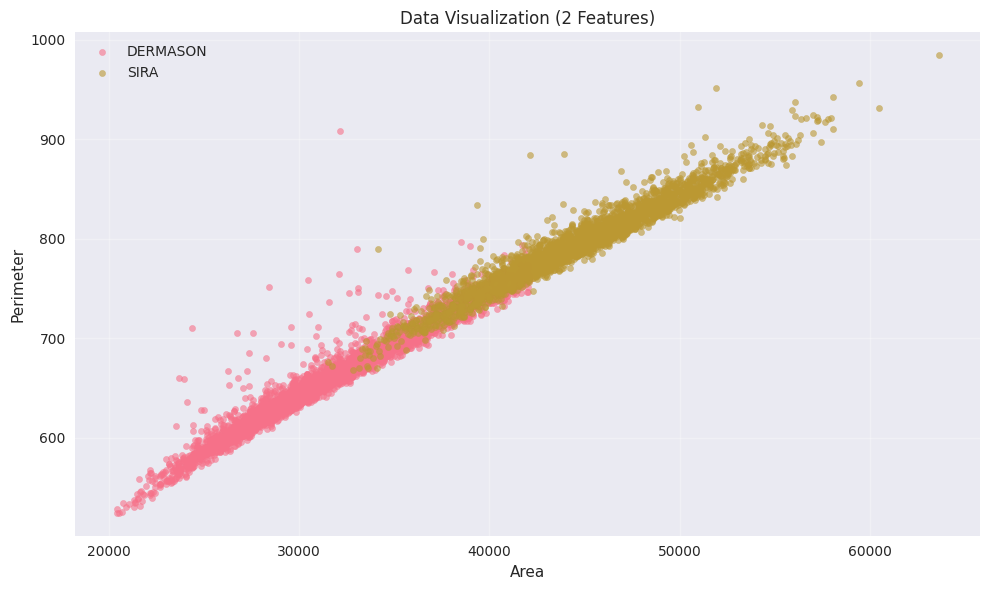

In [4]:
# Visualize the data - select 2 features for visualization
feature1_idx = 0  # Area
feature2_idx = 1  # Perimeter

X_vis = X_binary[:, [feature1_idx, feature2_idx]]
feature_names = X.columns.tolist()

plt.figure(figsize=(10, 6))
for class_label in np.unique(y_binary_encoded):
    mask = y_binary_encoded == class_label
    plt.scatter(X_vis[mask, 0], X_vis[mask, 1], 
                label=f'{label_encoder.inverse_transform([class_label])[0]}', 
                alpha=0.6, s=20)
plt.xlabel(feature_names[feature1_idx])
plt.ylabel(feature_names[feature2_idx])
plt.title('Data Visualization (2 Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [5]:
# Prepare data for training (using 2 features for decision boundary visualization)
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_binary, y_binary_encoded, test_size=0.2, random_state=42, stratify=y_binary_encoded
)

# For decision boundary plotting, use 2 features
X_train_2d = X_train_full[:, [feature1_idx, feature2_idx]]
X_test_2d = X_test_full[:, [feature1_idx, feature2_idx]]

# Standardize features
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Add intercept term (column of ones)
X_train_2d_scaled = np.hstack([np.ones((X_train_2d_scaled.shape[0], 1)), X_train_2d_scaled])
X_test_2d_scaled = np.hstack([np.ones((X_test_2d_scaled.shape[0], 1)), X_test_2d_scaled])

print(f"Training set shape: {X_train_2d_scaled.shape}")
print(f"Test set shape: {X_test_2d_scaled.shape}")


Training set shape: (4945, 3)
Test set shape: (1237, 3)


## 2. Sigmoid Function


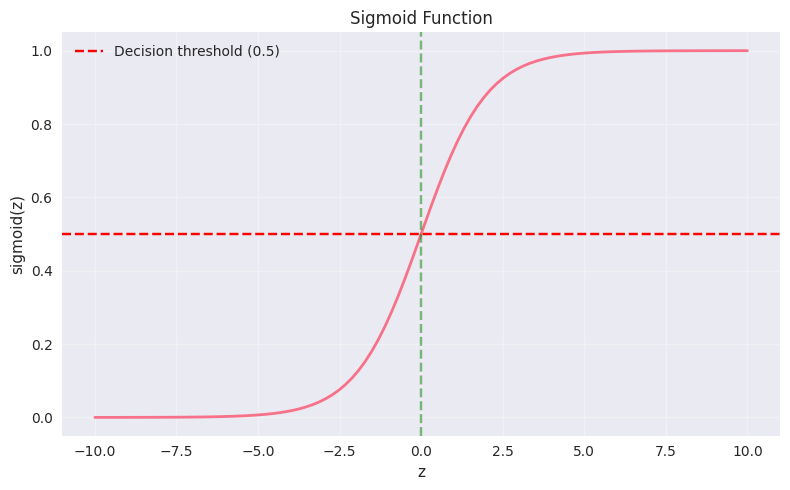

In [6]:
def sigmoid(z):
    """
    Compute the sigmoid function.
    
    Parameters:
    z: array-like, input values
    
    Returns:
    sigmoid values
    """
    # Clip z to prevent numerical overflow when computing exp(-z)
    # For very negative z (e.g., z < -500), exp(-z) = exp(|z|) becomes extremely large
    # and can overflow to inf, causing numerical instability.
    # For z <= -500, sigmoid(z) ≈ 0.0 (within machine precision)
    # For z >= 500, sigmoid(z) ≈ 1.0 (within machine precision)
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Visualize sigmoid function
z = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z)

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid_values, linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 3. Cost Function


In [58]:
def compute_cost(X, y, w, b, lambda_= 1):
    """
    Computes the cost over all examples (VECTORIZED VERSION)
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost 
    """
    m = X.shape[0]
    
    # Vectorized computation: z = X @ w + b for all examples at once
    z = X @ w + b
    
    # Vectorized sigmoid computation
    f_wb = sigmoid(z)
    
    # Vectorized cost computation using element-wise operations
    # Avoid log(0) by using np.clip or adding small epsilon
    epsilon = 1e-15
    f_wb = np.clip(f_wb, epsilon, 1 - epsilon)
    
    # Binary cross-entropy loss: -y*log(f) - (1-y)*log(1-f)
    loss = -y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)
    
    # Average loss
    total_cost = np.mean(loss)
    
    return total_cost

# Test the cost function with initial parameters
initial_w = np.zeros(X_train_2d_scaled.shape[1])
initial_b = 0.
initial_cost = compute_cost(X_train_2d_scaled, y_train_full, initial_w, initial_b)
print(f"Initial cost with zero parameters: {initial_cost:.4f}")


Initial cost with zero parameters: 0.6931


## 4. Gradient


In [59]:
# UNQ_C3
# GRADED FUNCTION: compute_gradient
def compute_gradient(X, y, w, b, lambda_=None): 
    """
    Computes the gradient for logistic regression (VECTORIZED VERSION)
 
    Args:
      X : (ndarray Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) values of parameters of the model      
      b : (scalar)                 value of parameter of the model 
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
    """
    m = X.shape[0]
    
    # Vectorized computation: z = X @ w + b for all examples at once
    z = X @ w + b
    
    # Vectorized sigmoid computation
    f_wb = sigmoid(z)
    
    # Vectorized error computation: error = f_wb - y for all examples
    err = f_wb - y
    
    # Vectorized gradient computation
    # dj_db = mean(err) = mean(f_wb - y)
    dj_db = np.mean(err)
    
    # dj_dw = mean(err * X) = mean((f_wb - y) * X) for each feature
    # This is equivalent to: X.T @ err / m
    dj_dw = (X.T @ err) / m
    
    return dj_db, dj_dw

# Test the gradient function
dj_db, dj_dw = compute_gradient(X_train_2d_scaled, y_train_full, initial_w, initial_b)
print(f"Initial gradient shape: {dj_db.shape} {dj_dw.shape}")
print(f"Initial gradient values: {dj_db} {dj_dw}")


Initial gradient shape: () (3,)
Initial gradient values: 0.07350859453993933 [ 0.07350859 -0.39854669 -0.3981801 ]


## 5. Learning Parameters using Gradient Descent


In [60]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant
      
    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% np.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

# Train the model
print("Training logistic regression model...")
alpha = 0.01  # Learning rate
num_iters = 1000  # Number of iterations

w, b, J_history,_ = gradient_descent(
    X_train_2d_scaled, y_train_full, initial_w, initial_b,
    compute_cost, compute_gradient, alpha, num_iters, 0
)

print(f"\nFinal parameters (w)(b): {w} {b}")


Training logistic regression model...
Iteration    0: Cost     0.69   
Iteration  100: Cost     0.48   
Iteration  200: Cost     0.39   
Iteration  300: Cost     0.34   
Iteration  400: Cost     0.31   
Iteration  500: Cost     0.29   
Iteration  600: Cost     0.27   
Iteration  700: Cost     0.26   
Iteration  800: Cost     0.25   
Iteration  900: Cost     0.25   
Iteration  999: Cost     0.24   

Final parameters (w)(b): [-0.2423093   1.23814713  1.24063447] -0.24230929991051933


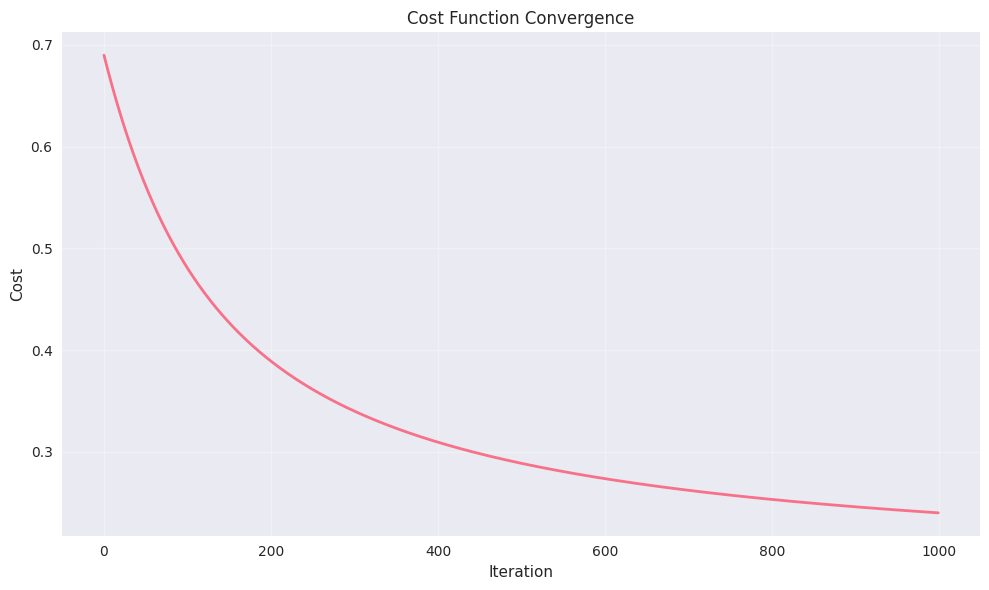

In [61]:
# Plot cost history
plt.figure(figsize=(10, 6))
plt.plot(J_history, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Plotting the Decision Boundary


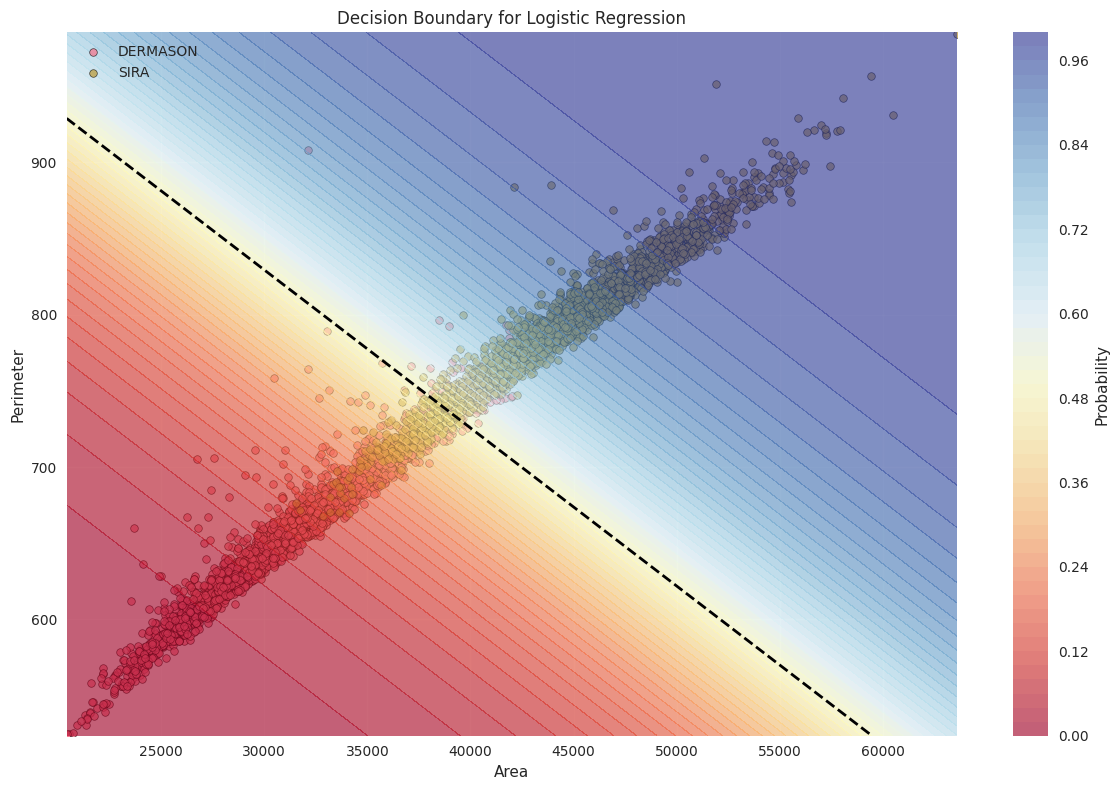

In [62]:
def map_feature(X1, X2, degree=6):
    """
    Feature mapping function to polynomial features (OPTIMIZED VERSION).
    
    Parameters:
    X1: array-like, first feature
    X2: array-like, second feature
    degree: int, degree of polynomial features (default 6)
    
    Returns:
    out: array, polynomial features
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    
    # Pre-allocate list for better performance
    out = []
    
    # Generate polynomial features using vectorized operations
    for i in range(1, degree+1):
        for j in range(i + 1):
            # Vectorized computation: X1**(i-j) * X2**j for all elements at once
            out.append((X1**(i-j) * (X2**j)))
    
    # Stack all features into a single array (more efficient than appending)
    return np.stack(out, axis=1)


def plot_decision_boundary(X, y, w, b, scaler, feature_names, label_encoder, use_polynomial=False, degree=6):
    """
    Plot the decision boundary for logistic regression.
    
    Parameters:
    X: array-like, feature matrix (original scale, 2 features)
    y: array-like, target vector
    w: array-like, learned weight parameters (without intercept)
    b: scalar, learned bias parameter
    scaler: StandardScaler, fitted scaler (only used if use_polynomial=False)
    feature_names: list, names of the two features
    label_encoder: LabelEncoder, fitted label encoder
    use_polynomial: bool, whether to use polynomial features (default False)
    degree: int, degree of polynomial features if use_polynomial=True (default 6)
    """
    # Plot data points
    plt.figure(figsize=(12, 8))
    for class_label in np.unique(y):
        mask = y == class_label
        plt.scatter(X[mask, 0], X[mask, 1], 
                   label=f'{label_encoder.inverse_transform([class_label])[0]}',
                   alpha=0.7, s=30, edgecolors='black', linewidth=0.5)
    
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    if use_polynomial:
        # Polynomial features case - VECTORIZED
        # Flatten mesh grid for vectorized processing
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        
        # Vectorized polynomial feature mapping for all points at once
        # This is much faster than nested loops
        poly_features = map_feature(mesh_points[:, 0], mesh_points[:, 1], degree)
        
        # Vectorized sigmoid computation for all points
        z = sigmoid(poly_features @ w + b)
        
        # Reshape back to mesh grid shape
        z = z.reshape(xx.shape)
        
        # Plot probability map
        plt.contourf(xx, yy, z, levels=50, alpha=0.6, cmap='RdYlBu')
        plt.colorbar(label='Probability')
        
        # Plot decision boundary
        plt.contour(xx, yy, z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    else:
        # Linear case: z = w[0]*x1_scaled + w[1]*x2_scaled + b
        # We need to work in original feature space, then scale
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        mesh_points_scaled = scaler.transform(mesh_points)
        # Calculate z = w @ x_scaled + b
        Z = sigmoid(mesh_points_scaled @ w + b)
        Z = Z.reshape(xx.shape)
        
        # Plot probability map
        plt.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
        plt.colorbar(label='Probability')
        
        # Plot decision boundary
        plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    title = 'Decision Boundary for Logistic Regression'
    if use_polynomial:
        title += f' (Polynomial degree {degree})'
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Extract feature weights (w might include intercept if X has intercept column)
# If w has 3 elements and X_train_2d_scaled has intercept, use w[1:] as feature weights
if len(w) == 3:  # w includes intercept term
    w_features = w[1:]  # Extract feature weights (skip intercept)
    b_total = w[0] + b  # Combine intercept from w and bias b
else:
    w_features = w  # w is already just feature weights
    b_total = b  # Use b as bias

# Plot decision boundary
plot_decision_boundary(
    X_train_2d, y_train_full, w_features, b_total, scaler_2d, 
    [feature_names[feature1_idx], feature_names[feature2_idx]], 
    label_encoder
)


## 7. Evaluating Logistic Regression


In [63]:
def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w (VECTORIZED VERSION)
    
    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,))
        The predictions for X using a threshold at 0.5
    """
    # Vectorized computation: z = X @ w + b for all examples at once
    z = X @ w + b
    
    # Vectorized sigmoid computation
    f_wb = sigmoid(z)
    
    # Vectorized prediction: p = (f_wb >= 0.5) for all examples
    p = (f_wb >= 0.5).astype(int)
    
    return p

# Make predictions
y_train_pred = predict(X_train_2d_scaled, w, b)
y_test_pred = predict(X_test_2d_scaled, w, b)

# Calculate accuracy
train_accuracy = accuracy_score(y_train_full, y_train_pred)
test_accuracy = accuracy_score(y_test_full, y_test_pred)

print("Training Results:")
print(f"  Accuracy: {train_accuracy:.4f}")
print(f"  Cost: {compute_cost(X_train_2d_scaled, y_train_full, w, b):.4f}")
print("\nTest Results:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Cost: {compute_cost(X_test_2d_scaled, y_test_full, w, b):.4f}")

# Classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test_full, y_test_pred, 
                          target_names=[label_encoder.inverse_transform([0])[0], 
                                       label_encoder.inverse_transform([1])[0]]))


Training Results:
  Accuracy: 0.9137
  Cost: 0.2402

Test Results:
  Accuracy: 0.9022
  Cost: 0.2492

Classification Report (Test Set):
              precision    recall  f1-score   support

    DERMASON       0.93      0.89      0.91       710
        SIRA       0.87      0.91      0.89       527

    accuracy                           0.90      1237
   macro avg       0.90      0.90      0.90      1237
weighted avg       0.90      0.90      0.90      1237



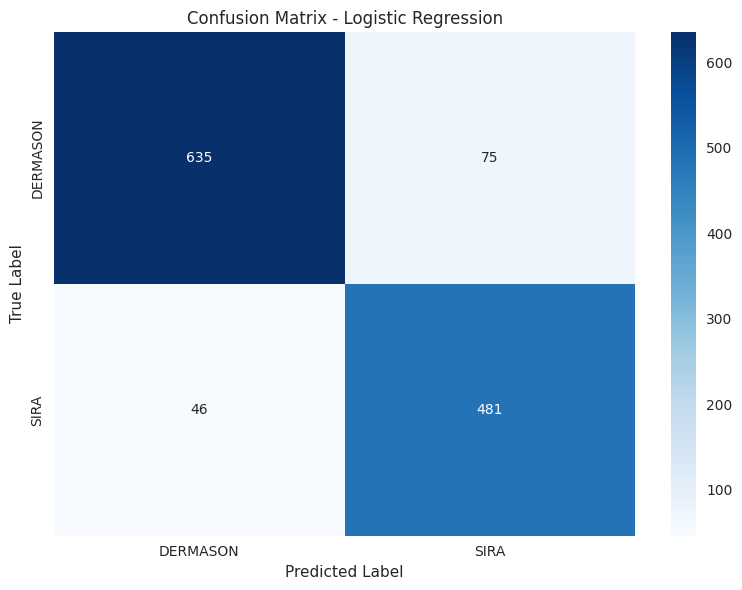

In [64]:
# Confusion matrix
cm = confusion_matrix(y_test_full, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]],
            yticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


# Regularized Logistic Regression

Now we'll implement regularized logistic regression with L2 regularization (Ridge).


## 1. Loading and Visualizing the Data (Regularized)

We'll use the same data as before.


In [65]:
# Use the same data prepared earlier
print("Using the same binary classification dataset")
print(f"Training set shape: {X_train_2d_scaled.shape}")
print(f"Test set shape: {X_test_2d_scaled.shape}")


Using the same binary classification dataset
Training set shape: (4945, 3)
Test set shape: (1237, 3)


## 2. Sigmoid Function (Regularized)

Same sigmoid function as before.


## 3. Cost Function (Regularized)


In [66]:
def compute_cost_regularized(X, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples (VECTORIZED VERSION)
    Args:
      X : (array_like Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : (scalar) Values of bias parameter of the model
      lambda_ : (scalar, float)    Controls amount of regularization
    Returns:
      total_cost: (scalar)         cost 
    """
    m = X.shape[0]
    
    # Calls the compute_cost function that you implemented above
    cost_without_reg = compute_cost(X, y, w, b) 
    
    # Vectorized regularization cost: sum of squares of w
    # reg_cost = sum(w^2) = w.T @ w = np.sum(w**2)
    reg_cost = np.sum(w**2)
    
    # Add the regularization cost to get the total cost
    total_cost = cost_without_reg + (lambda_/(2 * m)) * reg_cost

    return total_cost

# Test the regularized cost function
lambda_reg = 1.0
initial_cost_reg = compute_cost_regularized(X_train_2d_scaled, y_train_full, initial_w, initial_b, lambda_reg)
print(f"Initial regularized cost with zero parameters (lambda={lambda_reg}): {initial_cost_reg:.4f}")


Initial regularized cost with zero parameters (lambda=1.0): 0.6931


## 4. Gradient (Regularized)


In [67]:
def compute_gradient_regularized(X, y, w, b, lambda_ = 1): 
    """
    Computes the gradient for linear regression (VECTORIZED VERSION)
 
    Args:
      X : (ndarray Shape (m,n))   variable such as house size 
      y : (ndarray Shape (m,))    actual value 
      w : (ndarray Shape (n,))    values of parameters of the model      
      b : (scalar)                value of parameter of the model  
      lambda_ : (scalar,float)    regularization constant
    Returns
      dj_db: (scalar)             The gradient of the cost w.r.t. the parameter b. 
      dj_dw: (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w. 

    """
    m = X.shape[0]
    
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    # Vectorized regularization term: (lambda_ / m) * w
    # This adds regularization to all elements of dj_dw at once
    dj_dw = dj_dw + (lambda_ / m) * w
        
    return dj_db, dj_dw

# Test the regularized gradient function
initial_gradient_reg = compute_gradient_regularized(X_train_2d_scaled, y_train_full, initial_w, initial_b, lambda_reg)
print(f"Initial regularized gradient shape: {dj_db.shape} {dj_dw.shape}")
print(f"Initial regularized gradient values: {dj_db.tolist()} {dj_dw.tolist()}")


Initial regularized gradient shape: () (3,)
Initial regularized gradient values: 0.07350859453993933 [0.07350859453993933, -0.39854669303583545, -0.39818009645589875]


## 5. Learning Parameters using Gradient Descent (Regularized)


In [68]:
# Train the regularized model with different lambda values
lambda_values = [0.01, 0.1, 1.0, 10.0]
results_reg = {}

for lambda_reg in lambda_values:
    print(f"\n{'='*50}")
    print(f"Training with lambda = {lambda_reg}")
    print(f"{'='*50}")
    
    initial_w_reg = np.zeros(X_train_2d_scaled.shape[1])
    w_reg, b_reg, J_history, _ = gradient_descent(
        X_train_2d_scaled, y_train_full, initial_w_reg, initial_b,
        compute_cost_regularized, compute_gradient_regularized,
        alpha, num_iters, lambda_reg
    )
    
    results_reg[lambda_reg] = {
        'w': w_reg,
        'b': b_reg,
        'cost_history': J_history
    }
    
    print(f"Final cost (lambda={lambda_reg}): {J_history[-1]:.4f}")


Training with lambda = 0.01
Iteration    0: Cost     0.69   
Iteration  100: Cost     0.48   
Iteration  200: Cost     0.39   
Iteration  300: Cost     0.34   
Iteration  400: Cost     0.31   
Iteration  500: Cost     0.29   
Iteration  600: Cost     0.27   
Iteration  700: Cost     0.26   
Iteration  800: Cost     0.25   
Iteration  900: Cost     0.25   
Iteration  999: Cost     0.24   
Final cost (lambda=0.01): 0.2402

Training with lambda = 0.1
Iteration    0: Cost     0.69   
Iteration  100: Cost     0.48   
Iteration  200: Cost     0.39   
Iteration  300: Cost     0.34   
Iteration  400: Cost     0.31   
Iteration  500: Cost     0.29   
Iteration  600: Cost     0.27   
Iteration  700: Cost     0.26   
Iteration  800: Cost     0.25   
Iteration  900: Cost     0.25   
Iteration  999: Cost     0.24   
Final cost (lambda=0.1): 0.2402

Training with lambda = 1.0
Iteration    0: Cost     0.69   
Iteration  100: Cost     0.48   
Iteration  200: Cost     0.39   
Iteration  300: Cost     

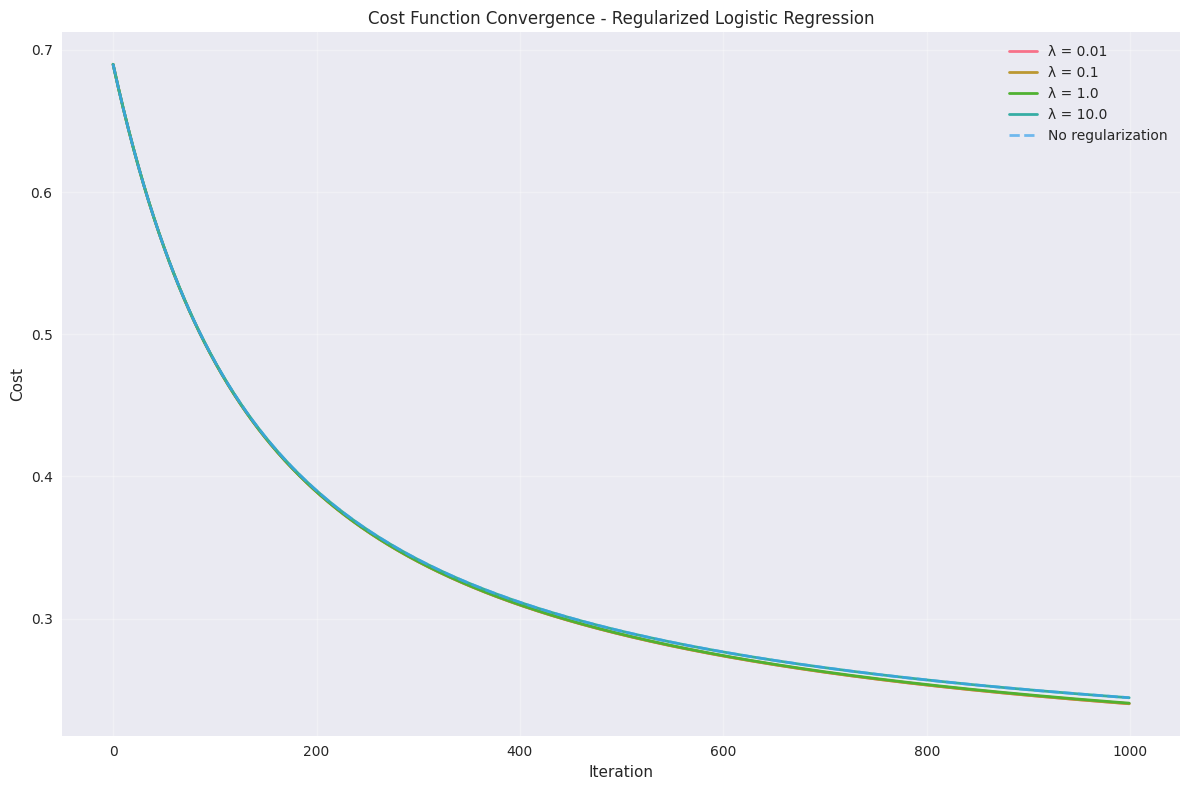

In [69]:
# Plot cost history for different lambda values
plt.figure(figsize=(12, 8))
for lambda_reg, result in results_reg.items():
    plt.plot(result['cost_history'], label=f'λ = {lambda_reg}', linewidth=2)

plt.plot(J_history, label='No regularization', linewidth=2, linestyle='--', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost Function Convergence - Regularized Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Plotting the Decision Boundary (Regularized)


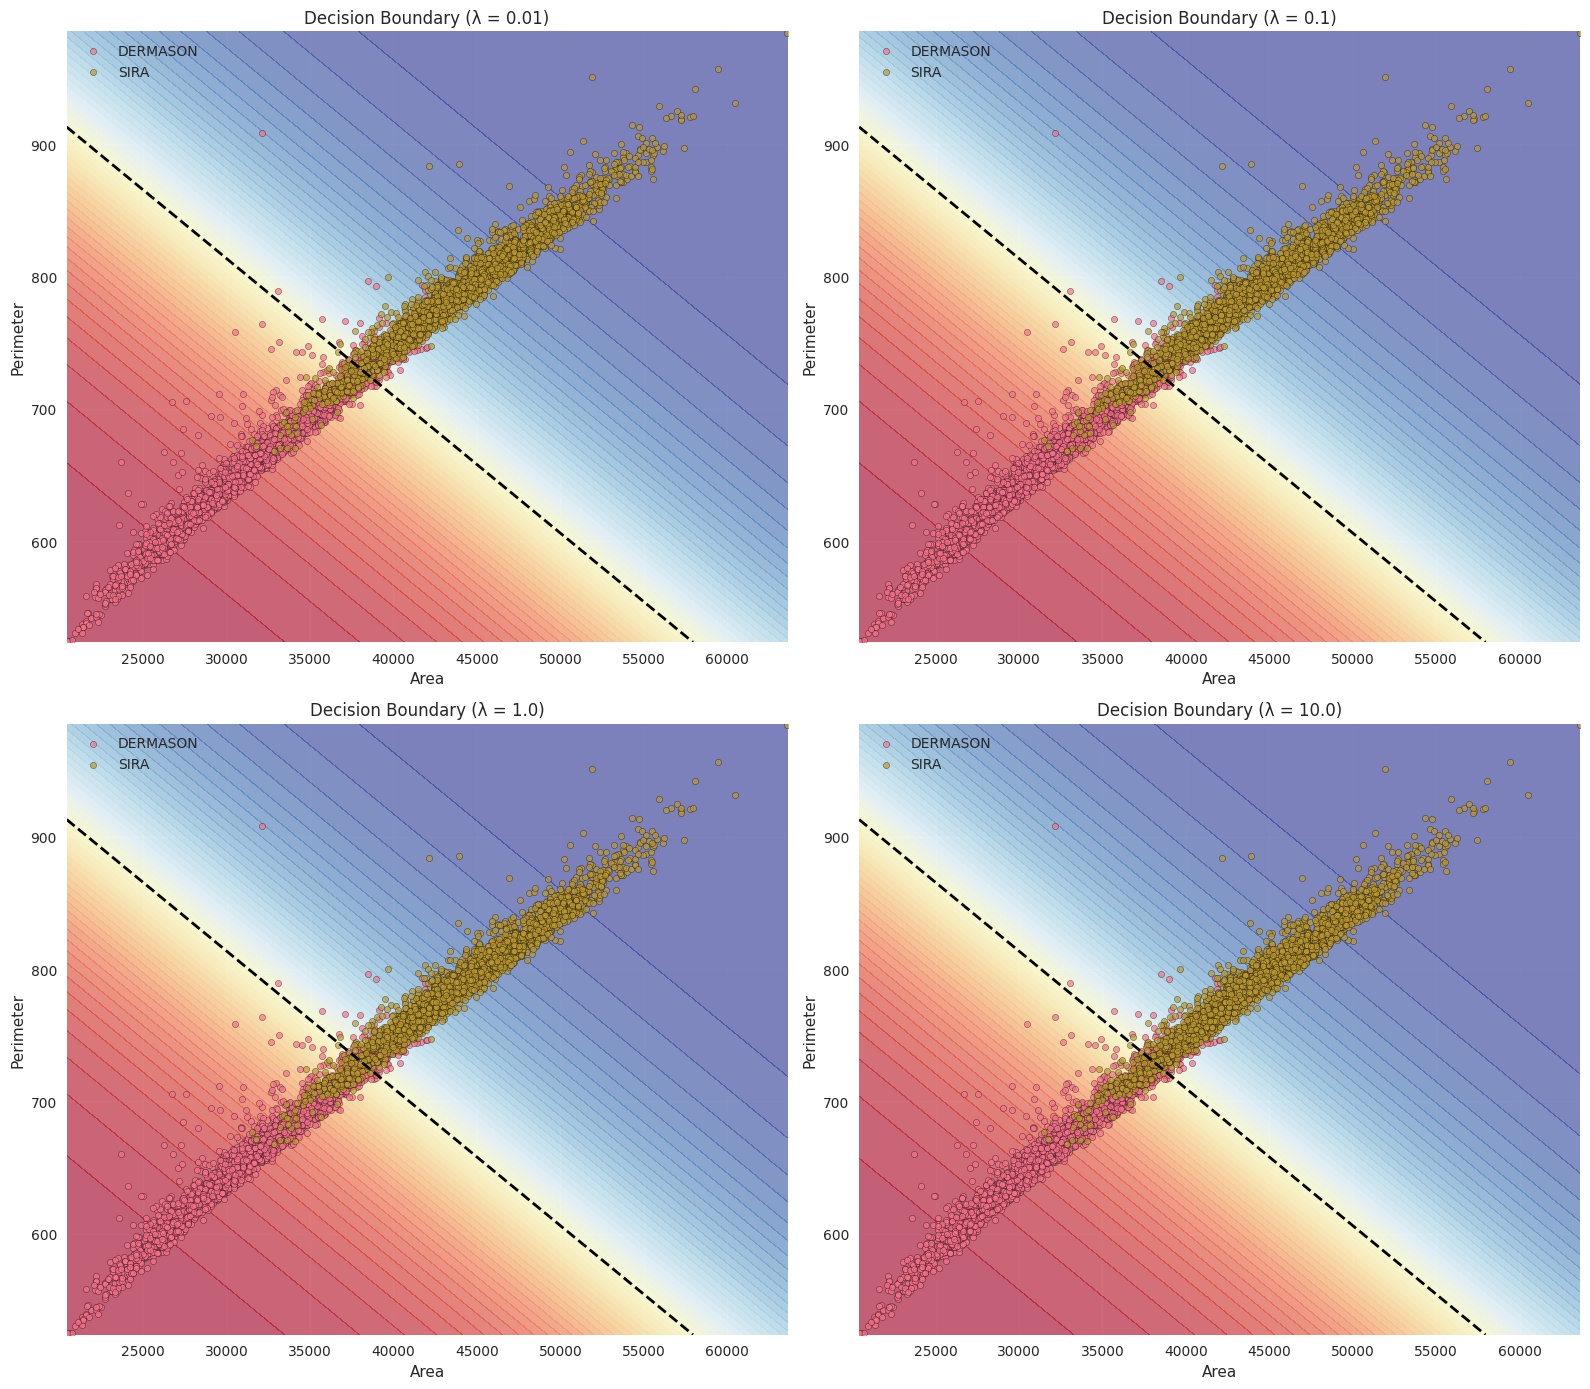

In [70]:
# Plot decision boundaries for different lambda values
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (lambda_reg, result) in enumerate(results_reg.items()):
    ax = axes[idx]
    w_reg = result['w']
    
    # Create a mesh grid
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Predict on mesh grid
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler_2d.transform(mesh_points)
    mesh_points_scaled = np.hstack([np.ones((mesh_points_scaled.shape[0], 1)), mesh_points_scaled])
    Z = sigmoid(mesh_points_scaled @ w_reg)
    Z = Z.reshape(xx.shape)
    
    # Plot
    contour = ax.contourf(xx, yy, Z, levels=50, alpha=0.6, cmap='RdYlBu')
    
    # Plot data points
    for class_label in np.unique(y_train_full):
        mask = y_train_full == class_label
        ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], 
                  label=f'{label_encoder.inverse_transform([class_label])[0]}',
                  alpha=0.7, s=20, edgecolors='black', linewidth=0.3)
    
    # Plot decision boundary
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    ax.set_xlabel(feature_names[feature1_idx])
    ax.set_ylabel(feature_names[feature2_idx])
    ax.set_title(f'Decision Boundary (λ = {lambda_reg})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluating Regularized Logistic Regression


In [71]:
# Evaluate models with different lambda values
print("Evaluation Results for Regularized Logistic Regression:\n")
print(f"{'Lambda':<10} {'Train Acc':<12} {'Test Acc':<12} {'Train Cost':<12} {'Test Cost':<12}")
print("-" * 60)

for lambda_reg, result in results_reg.items():
    w_reg = result['w']
    b_reg = result['b']
    
    # Predictions
    y_train_pred_reg = predict(X_train_2d_scaled, w_reg, b_reg)
    y_test_pred_reg = predict(X_test_2d_scaled, w_reg, b_reg)
    
    # Metrics
    train_acc_reg = accuracy_score(y_train_full, y_train_pred_reg)
    test_acc_reg = accuracy_score(y_test_full, y_test_pred_reg)
    train_cost_reg = compute_cost_regularized(X_train_2d_scaled, y_train_full, w_reg, b_reg, lambda_reg)
    test_cost_reg = compute_cost_regularized(X_test_2d_scaled, y_test_full, w_reg, b_reg, lambda_reg)
    
    print(f"{lambda_reg:<10.2f} {train_acc_reg:<12.4f} {test_acc_reg:<12.4f} {train_cost_reg:<12.4f} {test_cost_reg:<12.4f}")

# Compare with non-regularized
print("\n" + "-" * 60)
print("Non-regularized model:")
print(f"{'N/A':<10} {train_accuracy:<12.4f} {test_accuracy:<12.4f} {compute_cost(X_train_2d_scaled, y_train_full, w, b):<12.4f} {compute_cost(X_test_2d_scaled, y_test_full, w, b):<12.4f}")


Evaluation Results for Regularized Logistic Regression:

Lambda     Train Acc    Test Acc     Train Cost   Test Cost   
------------------------------------------------------------
0.01       0.9137       0.9022       0.2402       0.2493      
0.10       0.9137       0.9022       0.2402       0.2494      
1.00       0.9137       0.9022       0.2406       0.2506      
10.00      0.9134       0.9022       0.2444       0.2628      

------------------------------------------------------------
Non-regularized model:
N/A        0.9137       0.9022       0.2402       0.2492      


In [72]:
# Select best lambda based on test accuracy
best_lambda = max(results_reg.keys(), key=lambda l: accuracy_score(
    y_test_full, 
    predict(X_test_2d_scaled, results_reg[l]['w'], results_reg[l]['b'])
))

w_best = results_reg[best_lambda]['w']
b_best = results_reg[best_lambda]['b']
y_test_pred_best = predict(X_test_2d_scaled, w_best, b_best)

print(f"\nBest lambda value: {best_lambda}")
print(f"Test accuracy with best lambda: {accuracy_score(y_test_full, y_test_pred_best):.4f}")

# Classification report for best model
print("\nClassification Report (Test Set) - Best Regularized Model:")
print(classification_report(y_test_full, y_test_pred_best, 
                          target_names=[label_encoder.inverse_transform([0])[0], 
                                       label_encoder.inverse_transform([1])[0]]))



Best lambda value: 0.01
Test accuracy with best lambda: 0.9022

Classification Report (Test Set) - Best Regularized Model:
              precision    recall  f1-score   support

    DERMASON       0.93      0.89      0.91       710
        SIRA       0.87      0.91      0.89       527

    accuracy                           0.90      1237
   macro avg       0.90      0.90      0.90      1237
weighted avg       0.90      0.90      0.90      1237



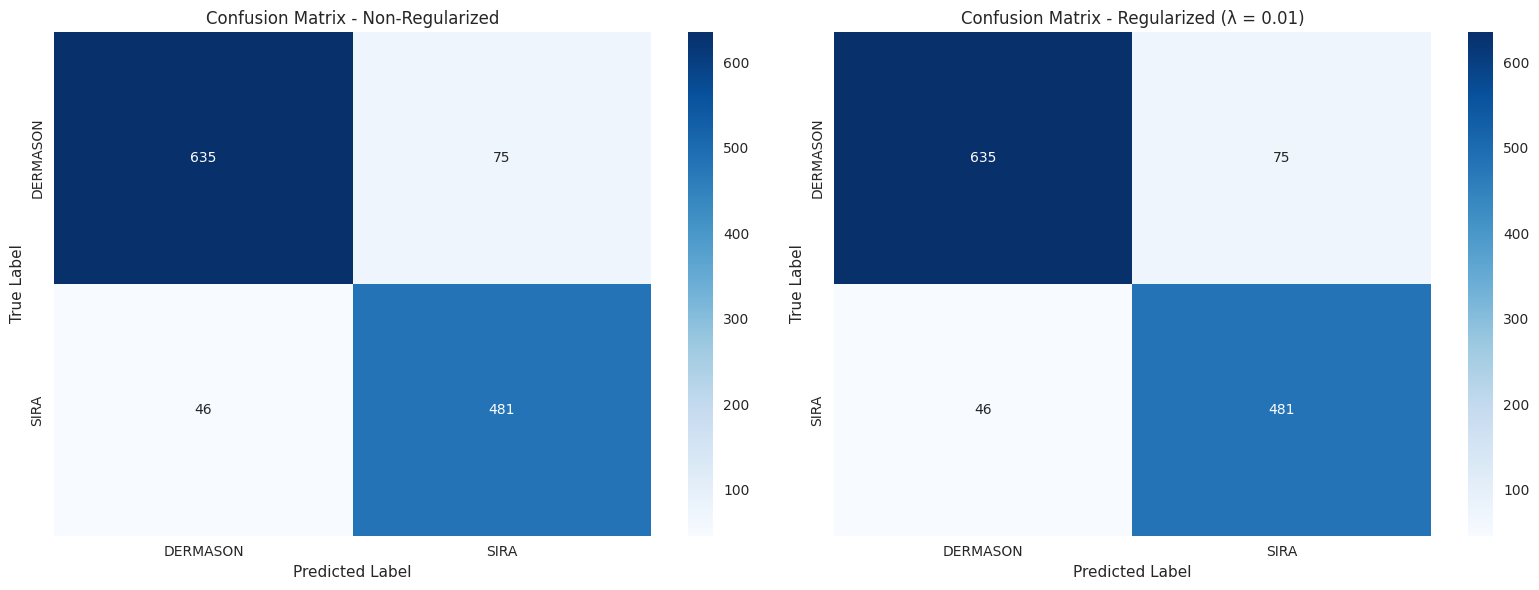

In [73]:
# Confusion matrix for best regularized model
cm_reg = confusion_matrix(y_test_full, y_test_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Non-regularized
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]],
            yticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]])
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_title('Confusion Matrix - Non-Regularized')

# Regularized
sns.heatmap(cm_reg, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]],
            yticklabels=[label_encoder.inverse_transform([0])[0], 
                        label_encoder.inverse_transform([1])[0]])
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_title(f'Confusion Matrix - Regularized (λ = {best_lambda})')

plt.tight_layout()
plt.show()


## Summary

This notebook implemented logistic regression from scratch, including:

1. **Data Loading and Visualization**: Loaded the Dry Bean Dataset and prepared it for binary classification
2. **Sigmoid Function**: Implemented the sigmoid activation function
3. **Cost Function**: Implemented the binary cross-entropy cost function
4. **Gradient**: Computed the gradient of the cost function
5. **Gradient Descent**: Learned parameters using iterative gradient descent
6. **Decision Boundary**: Visualized the decision boundary in 2D feature space
7. **Evaluation**: Assessed model performance using accuracy, classification report, and confusion matrix
8. **Regularized Logistic Regression**: Implemented all of the above with L2 regularization to prevent overfitting

The regularized version helps control model complexity and can improve generalization performance.
